# 

# Capstone Project: Crop Recommendation Machine Learning Model - Initial Report and Exploratort Data Analysis

## Overview

This initial report is to focus on understanding and preparing the agricultural dataset required to support a crop recommendation solution. The dataset is sourced from the USDA QuickStats database, contains state and county level crop production information, including yield, commodity type and year. The exploratory data analysis is to evaluate data completeness, consistency, on yield across regions and crops. Understanding data would support any need for data cleaning, feature engineering, and the selection of an appropriate baseline modeling approach, ensuring the data is reliable and suitable for subsequent detailed modeling and evaluation needs.


### Objective

The objective of this project is to deliver a data-driven capability that identifies and ranks the best-performing crops for a given state and county based on historical yield data. This solution is intended to support farmers, agricultural stakeholders, and agricultural lenders by assisting with information on suitable crops for planting, thereby improving crop selection decisions and regional crop risk assessment.



### Understanding the Data

The primary data source for this project is an agricultural production dataset containing state and county level crop information, including irrigated acreage and yield. The data is obtained from the USDA (United States Department of Agriculture) QuickStats database and is downloaded as a CSV report from https://quickstats.nass.usda.gov/ and converted to excel sheet. This dataset serves as the core data source for model training and evaluation.

### Read in the Data

In [28]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import time

In [29]:
crop_details = pd.read_excel("data/crop_details.xlsx")

In [30]:
crop_details.head()
crop_details["Commodity"].unique()


array(['CORN', 'SOYBEANS', 'COTTON', 'PEANUTS', 'SORGHUM', 'RICE', 'OATS',
       'WHEAT', 'BARLEY', 'HAY', 'TOBACCO', 'SUNFLOWER', 'SUGARCANE',
       'SUGARBEETS', 'BEANS', 'HAY & HAYLAGE'], dtype=object)

In [31]:
crop_details.head()

,Program,Year,Period,Week Ending,Geo Level,State,State ANSI,Ag District,Ag District Code,County,...,Zip Code,Region,watershed_code,Watershed,Commodity,Data Item,Domain,Domain Category,Value,CV (%)
0,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,148.3,3.1
1,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",TOTAL,NOT SPECIFIED,16.0,2.3
2,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,...,NaN,NaN,0,NaN,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,43.6,3.9
3,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,CENTRAL,50,BLAIR,...,NaN,NaN,0,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",TOTAL,NOT SPECIFIED,161.1,3.0
4,SURVEY,2024,YEAR,NaN,COUNTY,PENNSYLVANIA,42,CENTRAL,50,BLAIR,...,NaN,NaN,0,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",TOTAL,NOT SPECIFIED,18.0,3.1


In [32]:
# Ensuring all the data is captured with its description easy understand 
crop_details.attrs['Program']= "USDA provide the data as two programs SURVEY and CENSUS, this project chooses information \
collected as part of Survey Program."
crop_details.attrs["Year"] = "Year in which the data was collected."
crop_details.attrs["Period"] = "Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis."
crop_details.attrs["Geo Level"] = "Level at which the geographic detail was collected like STATE or COUNT"
crop_details.attrs["State"] = "Name of the state."
crop_details.attrs["State ANSI"] = "Numeric ANSI/FIPS code for the state."
crop_details.attrs["Ag District"] = "It is a designated geographic area, typically initiated by landowners and certified by \
state/local governments, designed to protect and promote active farming."
crop_details.attrs["Ag District Code"]  = "Code for the agricultural district."
crop_details.attrs["County"] = "Name of the County in a state."
crop_details.attrs["County ANSI"]  = "Numeric ANSI/FIPS code for the county."
crop_details.attrs["Zip Code"] = "ZIP code at county level."
crop_details.attrs["Region"] = "Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. \
These regions are derived from cluster analysis of commodities produced, soil, climate, and water." 
crop_details.attrs["watershed_code"] = "Numeric code for watershed area."
crop_details.attrs["Watershed"]  = "It is defined as a specific area of land—ranging from small plots to vast regions—where all water,\
including rain and snowmelt, drains to a common outflow point, such as a creek, river, lake, or reservoir."
crop_details.attrs["Commodity"] = "Type of Crop type."
crop_details.attrs["Data Item"] = "It is a field that provide a combination of crop sub type and yield measured in BU(Bushels) \
or Tonnes per Acre"
crop_details.attrs["Domain"] = "It refers to the sub-classification attribute used to break down or subset a data item, \
such as production, acreage, or yield. With classification of measurement in TOTAL or IRRIGATED.\
This project choose to limit the data attributes for TOTAL based on  yield."
crop_details.attrs["Domain Category"] = "Subcategory of domain is not specified by USDA." 
crop_details.attrs

{'Program': 'USDA provide the data as two programs SURVEY and CENSUS, this project chooses information collected as part of Survey Program.',
 'Year': 'Year in which the data was collected.',
 'Period': 'Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis.',
 'Geo Level': 'Level at which the geographic detail was collected like STATE or COUNT',
 'State': 'Name of the state.',
 'State ANSI': 'Numeric ANSI/FIPS code for the state.',
 'Ag District': 'It is a designated geographic area, typically initiated by landowners and certified by state/local governments, designed to protect and promote active farming.',
 'Ag District Code': 'Code for the agricultural district.',
 'County': 'Name of the County in a state.',
 'County ANSI': 'Numeric ANSI/FIPS code for the county.',
 'Zip Code': 'ZIP code at county level.',
 'Region': 'Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. These regions are de

# Data Understanding & Observations
There are a total of 31,770 entries spread across 11 states and 615 counties. The scope of this project has been intentionally limited to these 11 states, with the understanding that the solution can be scaled to include additional states in the future based on scope and business requirements.

## Data Features and Descriptions 
* Program – USDA provide the data as two programs SURVEY and CENSUS, this project chooses information collected as part of Survey Program.
* Year – Year in which the data was collected.
* Period – Reporting period (e.g., YEAR). this project choose to evaluate information collected on yearly basis.
* Geo Level – Level at which the geographic detail was collected like STATE or COUNTY.
* State – Name of the state.
* State ANSI – Numeric ANSI/FIPS code for the state.
* Ag District –  It is a designated geographic area, typically initiated by landowners and certified by state/local governments, designed to protect and promote active farming.
* Ag District Code – Code for the agricultural district.
* County – Name of the County in a state.
* County ANSI – Numeric ANSI/FIPS code for the county.
* Zip Code – ZIP code at county level.
* Region – Farm Resource Regions are categorized on shared characteristics rather than rigid state boundaries. These regions are derived from cluster analysis of commodities produced, soil, climate, and water. 
* watershed_code – Numeric code for watershed area.
* Watershed – It is defined as a specific area of land—ranging from small plots to vast regions—where all water, including rain and snowmelt, drains to a common outflow point, such as a creek, river, lake, or reservoir.
* Commodity – Type of Crop
* Data Item – It is a field that provide a combination of crop sub type and yield measured in BU(Bushels) or Tonnes per Acre 
* Domain – It refers to the sub-classification attribute used to break down or subset a data item , such as production, acreage, or yield. With classification of measurement in TOTAL or IRRIGATED. This project choose to limit the data attributes for TOTAL based on  yield.
* Domain Category – Subcategory of domain is not specified by USDA.

## Observations

* Several data attribues like **Program, Period, Geo Level, watershed_code, Domain and Domain Category** provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance.
    * Program has constant value "SURVEY"
    * Period has constant value "YEAR"
    * Geo Level has constant value "COUNTY"
    * watershed_code has constant value "'00000000"
    * Domain has constant value "TOTAL"
    * Domain Category has constant value "NOT SPECIFIED"

* Data attributes like **Week Ending, Zip Code, Region and Watershed** are empty.

* **Commodity** provides a generic classification of crops but does not capture further details such as specific varieties within the same crop for example **corn, grain vs silage**. The absence of this information may result in farmers, lenders, and other agricultural stakeholders making decisions based on less productive crop options. This limitation can increase lending risk, reduce farm profitability, and lead to higher inventory and operational costs for stakeholders that provide services across the crop production cycle.

* **Data Item** carries a significant amount of information, including sub-categories of crops and the associated yield measurements expressed in different units such as bushels or tonnes. The field by itself is not  useful for analysis and requires additional processing. Decomposing the Data Item into multiple structured features, such as crop sub-category and standardized yield units, enables more meaningful analysis and supports better outcomes for farmers, lenders, and other agricultural stakeholders.

* The **Value** of the crop can be misleading because yield values are represented in different units, such as bushels or tonnes, as indicated in the **Data Item** column. These values must be standardized to a common unit to enable correct prediction based on crop performance.

### Data Preparation

* Data attribues like Program, Period, Geo Level, watershed_code, Domain and Domain Category provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance, hence removing to simplify feature dimesions.
* Data attributes like Week Ending, Zip Code, Region and Watershed are empty, hence removing them to simplify feature dimesions

In [33]:
crop_df = crop_details.copy()
crop_df = crop_df.drop(
    columns=[
        "Program",
        "Period",
        "Geo Level",
        "watershed_code",
        "Domain",
        "Domain Category",
        "Week Ending",
        "Zip Code",
        "Region",
        "Watershed"
    ]
)
crop_df.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,Data Item,Value,CV (%)
0,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",148.3,3.1
1,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",16.0,2.3
2,2024,PENNSYLVANIA,42,NaN,99,OTHER COUNTIES,NaN,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",43.6,3.9
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",161.1,3.0
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",18.0,3.1


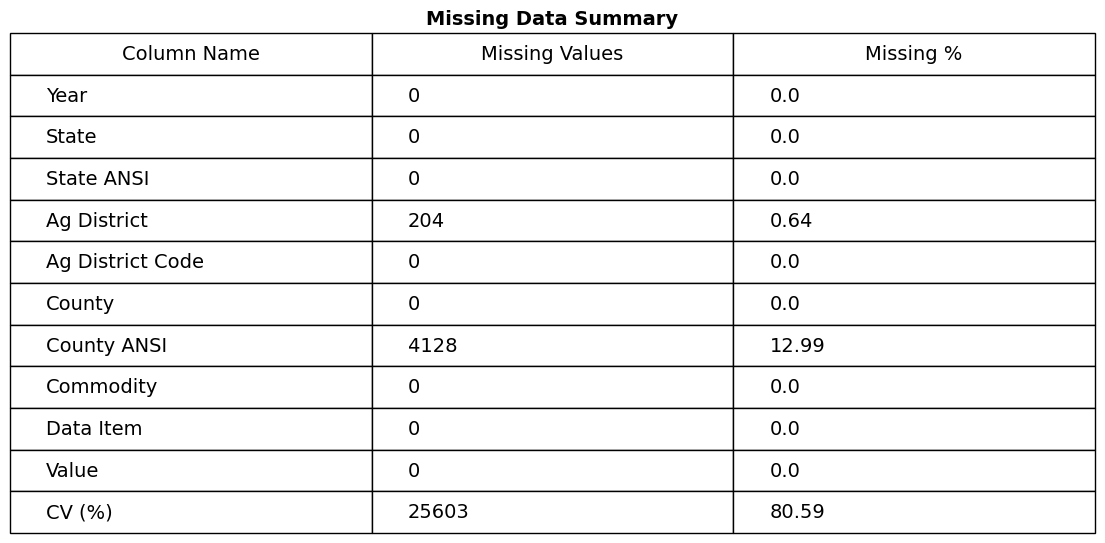

In [34]:

#  Understanding missing data patterns to determine appropriate imputation or removal strategies during data refinement.

crop_df.isna().sum()
missing_table = (
    crop_df.isna()
    .sum()
    .reset_index()
    .rename(columns={
        "index": "Column Name",
        0: "Missing Values"
    })
)
missing_table["Missing %"] = (
    missing_table["Missing Values"] / len(crop_df) * 100
).round(2)


fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
ax.set_title(
    "Missing Data Summary",
    fontsize=14,
    fontweight="bold",
    pad=20
)

table = ax.table(
    cellText=missing_table.values,
    colLabels=missing_table.columns,
    loc='center',
    cellLoc='left'
)

table.set_fontsize(14)
table.scale(1, 2.5)

plt.savefig(
    "images/missing_data_summary.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

# Missing Data Analysis
* Over 80% of the data is missing in **CV (%)**, which limits its usefulness for analysis and modeling. Given its high level of missingness and secondary relevance to crop prediction, retaining this column does not add meaningful value.
* **Ag District** has 204 missing values. Additionally, Ag District remains consistent for a given combination of State and County and does not provide additional variance beyond what is already captured by State and County. As a result, it is not relevant to the current business requirement.
* **County ANSI** is a coded representation of the County attribute and does not introduce additional dimensional variance compared to the County name itself. Replacing County with County ANSI for modeling purposes would require additional conversion logic between inputs and outputs without offering meaningful predictive benefits. 
* Based on these observations, removing the column **CV (%)** helps reduce dimensionality while retaining the most relevant features that directly impact prediction performance. While removal of columns like **Ag District and County ANSI** will be evaluated based on their on feature importance.

In [35]:
#  Removing column CV (%) as 80% of data is  missing

crop_df = crop_df.drop(
    columns=[
        "CV (%)"
    ]
)
crop_df.isna().sum()


Year                   0
State                  0
State ANSI             0
Ag District          204
Ag District Code       0
County                 0
County ANSI         4128
Commodity              0
Data Item              0
Value                  0
dtype: int64

In [36]:

# Data Clean up - Handling Missing County ANSI Codes
# Missing County ANSI values were replaced using the standard placeholder value 999, 
# which is commonly usedcode  in U.S. data systems to represent unknown or aggregated counties.
# This preserves dataset completeness while avoiding incorrect geographic misclassification.
crop_df["county_missing_flag"] = crop_df["County ANSI"].isna().astype(int)
crop_df["County ANSI"] = crop_df["County ANSI"].fillna(999)
crop_df["County ANSI"].isna().sum()

0

In [37]:

# Data Cleanup – Handling Missing Ag District Values by removing null records

original_records= crop_df.shape[0]
print(f'Size of crop dataset before dropping NaN: {original_records}')
crop_df = crop_df.dropna()
aft_del  = crop_df.shape[0]
print(f'Size of crop dataset after dropping NaN: {aft_del}')
print(f'Percentage of Data Dropped is: {round((((original_records-aft_del)/original_records)*100),2)}')



Size of crop dataset before dropping NaN: 31770
Size of crop dataset after dropping NaN: 31566
Percentage of Data Dropped is: 0.64


**Extraction of Structured Fields from Data Item:** The Data Item field contained multiple pieces of information embedded in text. This field was parsed to extract crop name, sub-category, and measurement unit, allowing these attributes to be represented as structured columns/features suitable for analysis and modeling.


In [38]:

# Extract crop name, sub category, and measurement unit from USDA Data Item field.
def parse_data_item(text):
    if pd.isna(text):
        return (None, None)
        
    # print(text)
    text = str(text)
    
    if " - " in text:
        before, after = text.split(" - ", 1)
        before, after = before.strip(), after.strip()
    else:
        before, after = text.strip(), ""
        
    # print(before, after)    
    if "," in before:
        sub_commodity = before.split(",", 1)[1].strip()
    else:
        sub_commodity =  before.strip()
    
    unit_match = re.search(r"MEASURED IN\s+(.*)", after)
    unit = unit_match.group(1).strip() if unit_match else None

    return pd.Series({"Sub_Commodity": sub_commodity, "Unit": unit})




In [39]:
# Data Conversion
# Create Sub Commodity and Unit of measurement columns
crop_df[["Sub_Commodity", "Unit"]] = crop_df["Data Item"].apply(parse_data_item)
crop_df.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,Data Item,Value,county_missing_flag,Sub_Commodity,Unit
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",161.1,0,GRAIN,BU / ACRE
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",18.0,0,SILAGE,TONS / ACRE
5,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,SOYBEANS,"SOYBEANS - YIELD, MEASURED IN BU / ACRE",54.9,0,SOYBEANS,BU / ACRE
6,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,"CORN, GRAIN - YIELD, MEASURED IN BU / ACRE",127.1,0,GRAIN,BU / ACRE
7,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,"CORN, SILAGE - YIELD, MEASURED IN TONS / ACRE",13.0,0,SILAGE,TONS / ACRE


**Standardization of Yield Units:** A yield conversion reference sheet was created through research using crop information available from USDA resources and other agricultural data sources. This reference was used to convert yield measurements reported in bushels per acre (BU/Acre) and tons per acre into a standardized unit of pounds per acre (lbs/acre). Standardizing yield units ensures that crop yields are comparable across different commodities and measurement systems.

In [40]:
yield_conv = pd.read_excel("data/yield_unit_conversion.xlsx")
yield_conv["Sub_Commodity"] = yield_conv["Sub_Commodity"].str.strip()
yield_conv.head()

,Meaurement,Commodity,Sub_Commodity,Conversion to LB,Example
0,BU / ACRE,BARLEY,BARLEY,48,80 bu/acre * 48 = 3840 lbs/acre
1,BU / ACRE,CORN,GRAIN,56,100 bu/acre * 56 = 5600 lbs/acre
2,BU / ACRE,OATS,OATS,32,100 bu/acre * 32 = 3200 lbs/acre
3,BU / ACRE,SORGHUM,GRAIN,56,100 bu/acre * 56 = 5600 lbs/acre
4,BU / ACRE,SOYBEANS,SOYBEANS,60,50 bu/acre * 60 = 3000 lbs/acre


**Standardization of Sub_Commodity Values:** The Sub_Commodity column was standardized by removing identifiers such as “irrigated” and “non-irrigated”. This ensures that the same crop sub-category is consistently represented across records, reducing category fragmentation and improving input quality

In [41]:

crop_df["Sub_Commodity"]= crop_df["Sub_Commodity"].str.replace(", IRRIGATED","")
crop_df["Sub_Commodity"]= crop_df["Sub_Commodity"].str.replace(", NON-IRRIGATED","")
main_sub = set(crop_df["Sub_Commodity"].dropna().unique())
conv_sub = set(yield_conv["Sub_Commodity"].dropna().unique())

# Find missing in conversions
missing_in_conversion = main_sub - conv_sub

print("Sub commodities missing in conversion sheet:")
print(missing_in_conversion)

missing_set = {
    'UPLAND, IRRIGATED', 'WINTER, IRRIGATED', 'GRAIN, IRRIGATED', 
    'AIR-CURED DARK (CLASS 3B)', 'GRAIN, NON-IRRIGATED', 
    'AIR-CURED LIGHT BURLEY (TYPE 31)', 'WINTER, NON-IRRIGATED', 
    'UPLAND, NON-IRRIGATED', 'NON-OIL TYPE', 
    'FIRE-CURED (CLASS 2)', 'OIL TYPE', 'FLUE-CURED (CLASS 1)'
}

filtered = (
    crop_df[
        crop_df["Sub_Commodity"].isin(missing_set)
    ][["Commodity","Sub_Commodity", "Unit"]]
    .drop_duplicates()
    .sort_values("Sub_Commodity")
)

print(filtered)

print("All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs")

Sub commodities missing in conversion sheet:
{'NON-OIL TYPE', 'AIR-CURED LIGHT BURLEY (TYPE 31)', 'AIR-CURED DARK (CLASS 3B)', 'FIRE-CURED (CLASS 2)', 'FLUE-CURED (CLASS 1)', 'OIL TYPE'}
       Commodity                     Sub_Commodity       Unit
13014    TOBACCO         AIR-CURED DARK (CLASS 3B)  LB / ACRE
8205     TOBACCO  AIR-CURED LIGHT BURLEY (TYPE 31)  LB / ACRE
8402     TOBACCO              FIRE-CURED (CLASS 2)  LB / ACRE
7817     TOBACCO              FLUE-CURED (CLASS 1)  LB / ACRE
7907   SUNFLOWER                      NON-OIL TYPE  LB / ACRE
7904   SUNFLOWER                          OIL TYPE  LB / ACRE
All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs


## Sub commodities missing in conversion sheet:
* NON-OIL TYPE, FLUE-CURED (CLASS 1), OIL TYPE, AIR-CURED LIGHT BURLEY (TYPE 31), AIR-CURED DARK (CLASS 3B), FIRE-CURED (CLASS 2)
* All the Sub commodities that are not mapped are in LB / Acre, which does not need conversion as our standard unit is LBs

In [42]:
crop_df["Unit"].unique()

array(['BU / ACRE', 'TONS / ACRE', 'LB / ACRE', 'TONS / ACRE, DRY BASIS'],
      dtype=object)

In [65]:


# Data Cleanup – Yield Unit Standardization

# All crop yield measurements were converted to a standardized unit (pounds/lbs per acre).
# After normalization, the original Unit and pre-conversion Value columns were removed.
# Since all yields are now expressed in a consistent unit, retaining the original
# measurement units and raw values is unnecessary for modeling.

def conv_to_lbs(commodity, sub_commodity, unit, value):
    
    # If value is missing, return as is
    if pd.isna(value):
        return value
    
    # Only convert BU / ACRE", TONS / ACRE
    if unit in ["BU / ACRE", "TONS / ACRE"]:
        
        # finding matching conversion metric
        conv_row = yield_conv[
            (yield_conv["Commodity"] == commodity) &
            (yield_conv["Sub_Commodity"] == sub_commodity)
        ]
        
        if not conv_row.empty:
            conv_metric = conv_row["Conversion to LB"].iloc[0]
            return value * conv_metric
        
        else:
            # No conversion mapping found
            return value
    
    else:
        return value


crop_df["std_yield"] = crop_df.apply(
    lambda row: conv_to_lbs(
        row["Commodity"],
        row["Sub_Commodity"],
        row["Unit"],
        row["Value"]
    ),
    axis=1
)


crop_df_clean = crop_df.drop(["Data Item", "Unit", "Value"], axis=1)

crop_df_clean.to_excel('data/crop_clean_data.xlsx')
crop_df_clean.head()

,Year,State,State ANSI,Ag District,Ag District Code,County,County ANSI,Commodity,county_missing_flag,Sub_Commodity,std_yield
3,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,0,GRAIN,9021.6
4,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,CORN,0,SILAGE,36000.0
5,2024,PENNSYLVANIA,42,CENTRAL,50,BLAIR,13.0,SOYBEANS,0,SOYBEANS,54.9
6,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,0,GRAIN,7117.6
7,2024,PENNSYLVANIA,42,CENTRAL,50,CAMBRIA,21.0,CORN,0,SILAGE,26000.0


### Summary of Data Cleanup and Preparation
* Data attribues like Program, Period, Geo Level, watershed_code, Domain and Domain Category provided by USDA contains constant or non-informative values. Therefore, will not contribute to predictive performance, hence removing to simplify feature dimesions.
* Data attributes like Week Ending, Zip Code, Region and Watershed are empty, hence removing them to simplify feature dimesions
* Removal of CV (%) Column: The CV (%) column was removed because approximately 80% of the values were missing, making it unreliable and not useful for meaningful analysis or modeling.
* Handling Missing County ANSI Codes: Missing values in the County ANSI column were replaced with the placeholder value 999, which is commonly used in U.S. data systems to represent unknown or aggregated counties. This approach preserves dataset completeness while avoiding incorrect misclassification.
* Extraction of Structured Fields from Data Item: The Data Item field contained multiple pieces of information embedded in text. This field was parsed to extract crop name, sub-category, and measurement unit, allowing these attributes to be represented as structured columns/features suitable for analysis and modeling.
* Standardization of Sub_Commodity Values: The Sub_Commodity column was standardized by removing identifiers such as “irrigated” and “non-irrigated”. This ensures that the same crop sub-category is consistently represented across records, reducing category fragmentation and improving input quality.
* Standardization of Yield Units: A yield conversion reference sheet was created through research using crop information available from USDA resources and other agricultural data sources. This reference was used to convert yield measurements reported in bushels per acre (BU/Acre) and tons per acre into a standardized unit of pounds per acre (lbs/acre). Standardizing yield units ensures that crop yields are comparable across different commodities and measurement systems.

# Graphical Representations of Data

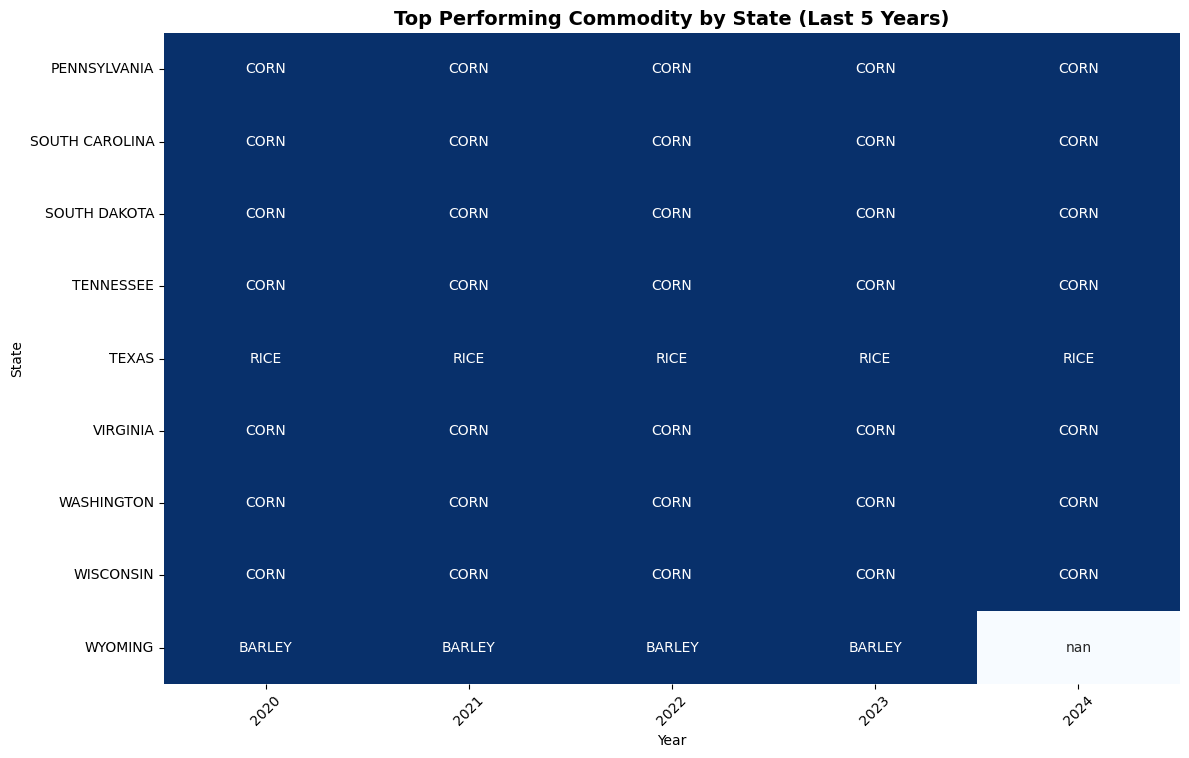

In [66]:
#  Top Performing Commodity by State (Last 5 Years)

# Filter last 5 years
latest_year = crop_df_clean["Year"].max()
last_5 = crop_df_clean[crop_df_clean["Year"] >= latest_year - 4]

#  Aggregate crop yileds by State, Year, Commodity
state_year_agg = (
    last_5
    .groupby(["State", "Year", "Commodity"])["std_yield"]
    .mean()
    .reset_index()
)

#  Get top crop of each state per year
top_by_state_year = (
    state_year_agg
    .sort_values(["State", "Year", "std_yield"], ascending=[True, True, False])
    .groupby(["State", "Year"])
    .first()
    .reset_index()
)

pivot_table = top_by_state_year.pivot(
    index="State",
    columns="Year",
    values="Commodity"
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table.notna(),
    annot=pivot_table,
    fmt="",
    cmap="Blues",
    cbar=False
)

plt.title(
    "Top Performing Commodity by State (Last 5 Years)",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/top_performing_commodity_state .png", dpi=300,bbox_inches="tight")
plt.show()


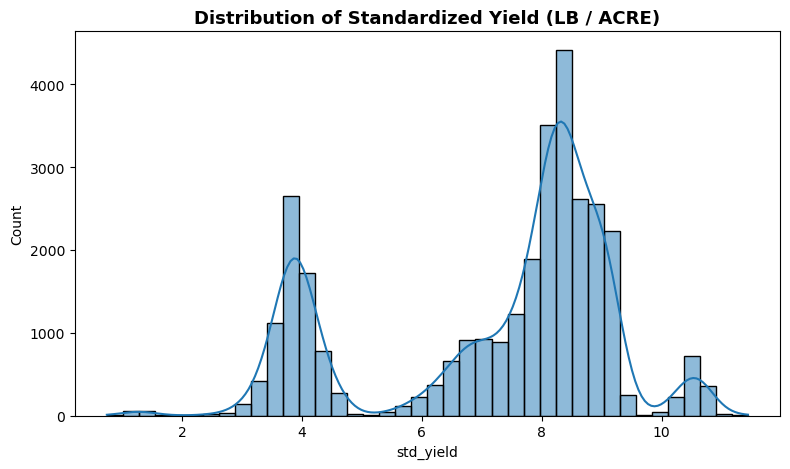

In [67]:
# Distribution of standardized yield
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(crop_df_clean["std_yield"]), bins=40, kde=True)
plt.title("Distribution of Standardized Yield (LB / ACRE)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/std_yield_dist.png", dpi=300,bbox_inches="tight")
plt.show()

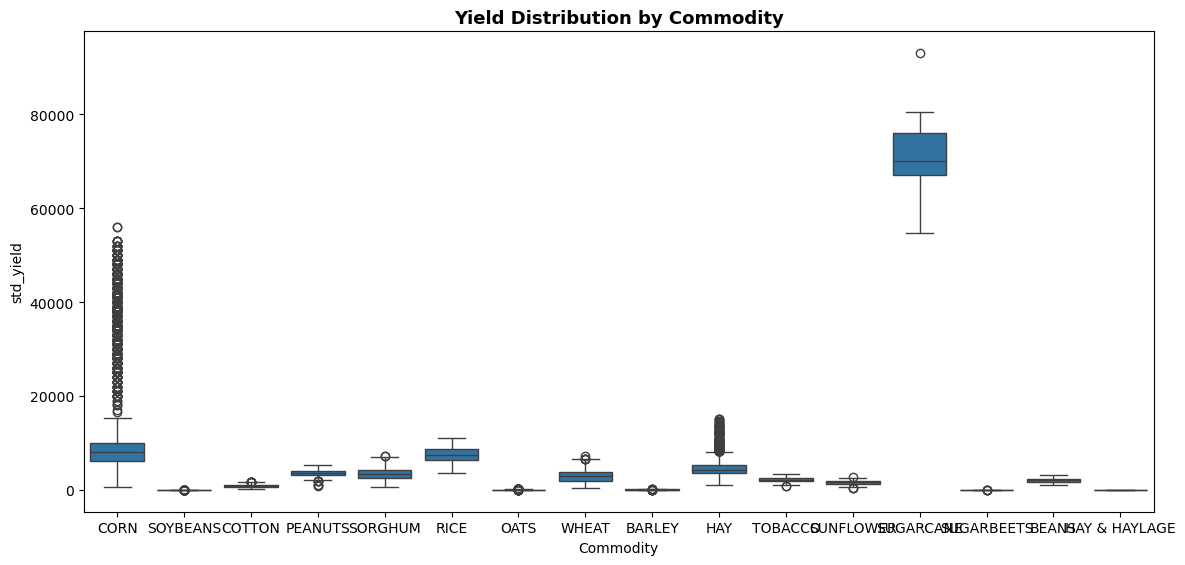

In [68]:
# Yield by Commodity
plt.figure(figsize=(12,6))
sns.boxplot(data=crop_df_clean, x="Commodity", y="std_yield")
plt.title("Yield Distribution by Commodity", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/yield_by_commodity.png", dpi=300,bbox_inches="tight")
plt.show()

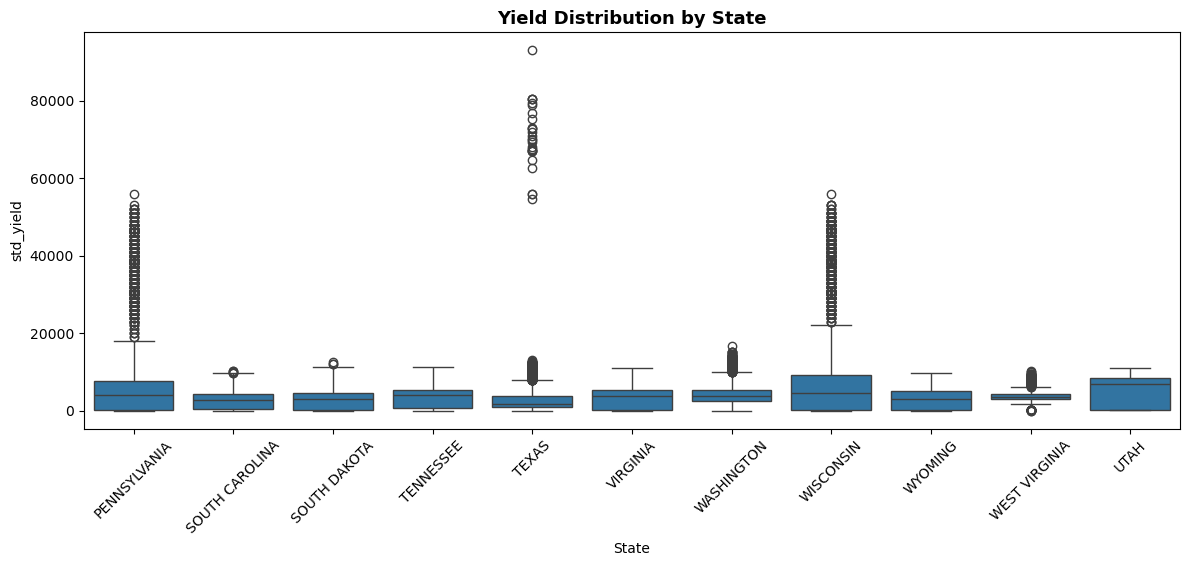

In [69]:
# Yield by State
plt.figure(figsize=(12,6))
sns.boxplot(data=crop_df_clean, x="State", y="std_yield")
plt.xticks(rotation=45)
plt.title("Yield Distribution by State", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/yield_by_state.png", dpi=300,bbox_inches="tight")
plt.show()

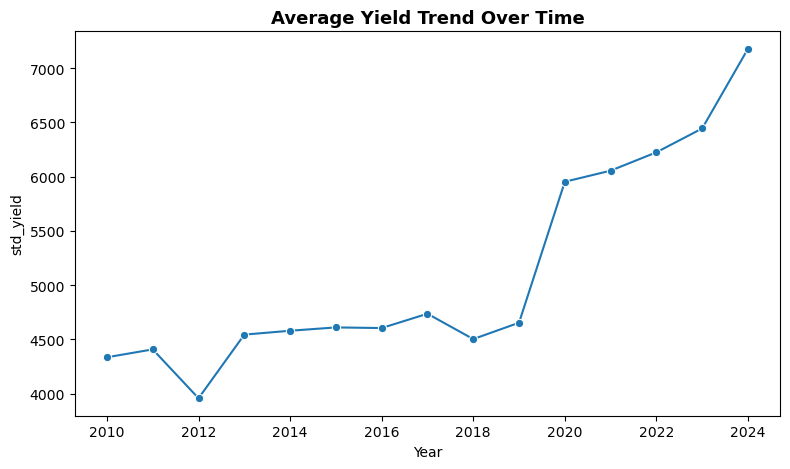

In [70]:
# Time Trend
year_trend = (
    crop_df_clean
    .groupby("Year")["std_yield"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=year_trend, x="Year", y="std_yield", marker="o")
plt.title("Average Yield Trend Over Time", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("images/avg_yield_over_time.png", dpi=300,bbox_inches="tight")
plt.show()

# Feature Engineering
The dataset contains both categorical and numeric attributes representing geographic, administrative, and yield related information. To prepare the data for modeling, features were grouped into categorical and numerical variables based on their characteristics and role in prediction.

In [71]:
crop_df_clean.columns

Index(['Year', 'State', 'State ANSI', 'Ag District', 'Ag District Code',
       'County', 'County ANSI', 'Commodity', 'county_missing_flag',
       'Sub_Commodity', 'std_yield'],
      dtype='object')


# Categorical Features
The following fields were treated as categorical variables because they represent geographic or administrative classifications rather than measurable numeric quantities:

    * State – Represents the U.S. state where the crop yield was recorded.
    * Ag District – Agricultural district grouping within a state.
    * County – County level geographic identifier.

# Numeric Features
The following variables were treated as numerical features because they represent quantitative values or encoded identifiers:

    * Year – Indicates the year of the agricultural observation and allows the model to capture trends in crop productivity.
    * State ANSI – Numeric code representing the state. 
    * Ag District Code – Numeric identifier for the agricultural district.
    * County ANSI – Numeric identifier for the county.
    * county_missing_flag – Binary indicator identifying records where the county code was originally missing and replaced with a placeholder.
    * std_yield – Standardized crop yield measured in pounds per acre, representing productivity of the crop.

# Target Variable
New target variable is constructed for following reasons:

    * To create a more precise prediction target, a new variable called target_crop was engineered by combining the Commodity and Sub_Commodity fields.
    * This approach ensures that the model predicts both the main crop category and its specific sub-category, enabling more granular crop recommendations.

In [72]:


#  All fetaures  'Year', 'State', 'State ANSI', 'Ag District', 'Ag District Code',
# 'County', 'County ANSI', 'Commodity', 'county_missing_flag', 'std_yield' are input features
# Except for 'Commodity' and 'Sub_Commodity' which will be predicted from our model


#  Below is the list of categorical and numeric features

cat_feats = [
    "State",
    "Ag District",
    "County"
]

num_feats = [
    "Year",
    "State ANSI",
    "Ag District Code",
    "County ANSI",
    "county_missing_flag",
    "std_yield"
]

In [73]:
#  Separting Features and Target
crop_df_clean["target_crop"] = (
    crop_df_clean["Commodity"].astype(str) + "_" +
    crop_df_clean["Sub_Commodity"].astype(str)
)

X = crop_df_clean[cat_feats + num_feats]
y = crop_df_clean["target_crop"]

### Problem 6: Train/Test Split

The dataset was divided into training and testing subsets to evaluate the performance of the machine learning models on unseen data.
   * A 70%–30% split was used
      * 70% of the data was used for training the model, allowing the algorithm to learn patterns.
      * 30% of the data was reserved as a test dataset to objectively evaluate model performance.

In [74]:

#  Create train and test data sets for inputs and target varibles
# Goal is to divide datasets by 70% for training and 30% for testing
#  Used parameter stratify=y for multi-class balance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ("num", StandardScaler(), num_feats)
    ]
)


In [76]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(22096, 9)
(9470, 9)
(22096,)
(9470,)


### Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [77]:
model_comp_other_cols = [
    "Model","Train Time",
    "Pred Time","Accuracy", "Precision",
    "Recall", "F1", "ROC AUC"] 
model_comp_more_metrics = pd.DataFrame(columns=model_comp_other_cols)

def add_mod_metrcis(model_name, train_time, metrics):
    model_comp_more_metrics.loc[len(model_comp_more_metrics)]=[
        model_name, 
        train_time, 
        metrics["predict_time"],
        metrics["accuracy"],
        metrics["precision"],
        metrics["recall"],
        metrics["f1"],
        metrics["roc_auc"]
    ]
    return model_comp_more_metrics
    

In [78]:
#  This function will calculate accuracy score, precision, recall
#  F1-score and ROC AOC and returns individual scores and dataframe with all scores scores
def get_eval_scores(model, modelname, X, y):
    pred_start_time = time.perf_counter()
    y_pred = model.predict(X)
    pred_end_time = time.perf_counter()
    pred_time = pred_end_time - pred_start_time
    acc_score = accuracy_score(y, y_pred)
    # catching subscribers is the goal, predicting no is not of much business value
    prec_yes = precision_score(y, y_pred, average='macro')
    recall_yes = recall_score(y, y_pred, average='macro')
    f1_yes = f1_score(y, y_pred, average='macro')
    
    # ROC AUC (only if the model provides probabilities)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)
        roc_auc = roc_auc_score(y, y_prob, multi_class='ovr', average='macro')
    # elif hasattr(model, "decision_function"):
    #     y_prob = model.decision_function(X)
    else:
        roc_auc = None
    
    # roc_auc_yes = (
    #     roc_auc_score(y, y_prob) if y_prob is not None else None
    # )

    # Prepare metrics in DataFrame
    eval_columns = [f"{modelname}(macro)", "Value"]
    baseline_metrcis = pd.DataFrame(columns= eval_columns)
    baseline_metrcis.loc[len(baseline_metrcis)]=["Accuracy", acc_score]
    baseline_metrcis.loc[len(baseline_metrcis)]=["Precision", prec_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["Recall", recall_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["F1 Score", f1_yes]
    baseline_metrcis.loc[len(baseline_metrcis)]=["ROC AUC", roc_auc]
    # return prec_yes, recall_yes, f1_yes, roc_auc_yes
    return {
        "predict_time": pred_time,
        "accuracy": acc_score,
        "precision": prec_yes,
        "recall": recall_yes,
        "f1": f1_yes,
        "roc_auc": roc_auc,
        "eval metrcis":baseline_metrcis
    }

In [79]:
crop_dummy_model = DummyClassifier(
    strategy="stratified",
    random_state=42
)
dummy_train_start_time = time.perf_counter()
crop_dummy_model.fit(X_train, y_train)
dummy_train_end_time = time.perf_counter()
dummy_train_time = dummy_train_end_time - dummy_train_start_time
baseline_metrcis = get_eval_scores(crop_dummy_model, "Dummy Classifier", X_test, y_test)
baseline_metrcis["eval metrcis"]
add_mod_metrcis("DummyClassifier", dummy_train_time, baseline_metrcis)


,Model,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,DummyClassifier,0.020597,0.005149,0.118268,0.041766,0.041935,0.041841,0.500171


### Dummy Classifier Observations
* Correctly predicts about 11–12% of samples
* Macro Precision / Recall / F1 is 0.04 that projects class imbalance, which means rare clases may never get predicted correctly
* ROC AUC is 0.5,  which means no discrimination and behaving correctly on random ranking

The stratified DummyClassifier achieved an accuracy of 11.8% with macro F1 of 0.042, establishing the statistical performance floor. Any model exceeding this baseline demonstrates learned predictive signal beyond random class distribution.


### Simple Model

Use Logistic Regression to build a basic model on your data.  

In [80]:
simp_lgr_pipe =  Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ))
])

lgr_train_start_time = time.perf_counter()
simp_lgr_pipe.fit(X_train, y_train)
lgr_train_end_time = time.perf_counter()
lgr_train_time = lgr_train_end_time - lgr_train_start_time

simp_lgr_metrics = get_eval_scores(simp_lgr_pipe, "Simple LogReg", X_test, y_test)
add_mod_metrcis("LogisticRegression", lgr_train_time, simp_lgr_metrics)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Train Time,Pred Time,Accuracy,Precision,Recall,F1,ROC AUC
0,DummyClassifier,0.020597,0.005149,0.118268,0.041766,0.041935,0.041841,0.500171
1,LogisticRegression,1.026913,0.006415,0.685956,0.547995,0.450691,0.480733,0.982624


## Logistic Regression Observations
* Accuracy (68.6%) is substantially higher than the Dummy baseline (11.8%).
* Precision indicates that more than half of predicted positives are correct.
* Recall demonstrates moderate ability to capture actual positives, suggesting potential improvement through threshold tuning.
* The macro ROC AUC of 0.98 indicates strong class separability and ranking capability.

## Overall Conclusion for Baseline and Simple (Logistic Regression) models

Logistic Regression significantly outperformed the Dummy classifier across all evaluation metrics. With 68.6% accuracy, macro F1 of 0.48, and a macro ROC AUC of 0.98, the model demonstrates strong discriminative ability.

The high ROC AUC suggests the model is well-suited for ranking-based applications such as top-3 crop recommendation, though further  optimization and class-level analysis may improve balanced performance across all crop categories.



#### Next Steps
* **Evaluate Multiple Classification Models:** Train and compare several classification algorithms like Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest and Support Vector Classifier (SVC). These models will help determine which algorithm best captures patterns in the agricultural dataset and produces reliable predictions.
* **Hyperparameter Tuning:** For each model will be evaluated by multiple hyperparameter configurations to optimize performance. Parameters such as the number of neighbors in KNN, tree depth in Decision Trees, number of estimators in Random Forest, and kernel parameters in SVC will be tested for best performing model configuration.
* **Ranking-Based Evaluation:** Since the objective of the project is to recommend suitable crops, the models will be evaluated not only on standard classification metrics but also on their ability to correctly rank crop predictions. Metrics such as Top-k accuracy for Top-3 recommendations will be used to measure top predicted options.
* **Feature Evaluation and Selection:** Analyze the contribution of each feature used in the model, including State, Agricultural District, County, Year, geographic codes, and standardized yield. Features will be evaluated to determine their impact on prediction accuracy and ranking performance.
* **Feature Reduction:** Identify features that can be removed without significantly affecting model performance. Eliminating non-informative features can reduce model complexity, improve interpretability, and potentially enhance model generalization.
* **Model Comparison and Selection:** Compare the performance of all trained models using consistent evaluation metrics such as accuracy, precision, recall, F1 score, ROC-AUC, and ranking performance.

**The model that demonstrates the best balance between predictive accuracy and ranking reliability will be selected as the final model for crop recommendation.**